# **B**ell-**L**inking **a**nd **R**emote **T**eleportation: A **SABRE** heuristic search algorithm (BLaRTSABRE)

## Single-core processor architecture


In the single processor setting, the hardware is modelled as a single **coupling graph** where each node is a physical qubit and each edge represents an allowed 2 qubit interaction (and SWAP). Circuit execution uses a **mapping** from logical qubits to physical qubits.

**Executability rule:** a 2 qubit gate on logical qubits `(q1, q2)` is directly executable if the architecture has an edge between the mapped physical qubits `(mapping.l_to_p(q1), mapping.l_to_p(q2))`. If no edge exists, routing must insert SWAPs (or equivalent operations) to make the interaction local.

We represent this single processor architecture with `QubitNetworkGraph`, which stores connectivity and edge weights and precomputes shortest path distances for use in routing and layout heuristics.

### How to construct a single-core processor architecture


for example, IBM Rochester (53 qubits) Quantum Device can be constructed as follows:

In [7]:
from architecture import QubitNetworkGraph

def rochester(offset: int = 0) -> QubitNetworkGraph:
    edges = []

    # linear segments
    I_1 = (
        list(range(4)) +
        list(range(7, 15)) +
        list(range(19, 27)) +
        list(range(30, 38)) +
        list(range(42, 50))
    )
    for i in I_1:
        edges.append((i + offset, i + 1 + offset))

    # cross links
    E = [
        (0, 5), (5, 9), (4, 6), (6, 13), (7, 16), (16, 19),
        (11, 17), (17, 23), (15, 18), (18, 27), (21, 28), (28, 32),
        (25, 29), (29, 36), (30, 39), (39, 42), (34, 40), (40, 46),
        (38, 41), (41, 50), (44, 51), (48, 52)
    ]
    for u, v in E:
        edges.append((u + offset, v + offset))

    return QubitNetworkGraph(edges, name=f"IBM Q Rochester (53 qubits, offset {offset})")


and can be visualised as follows:

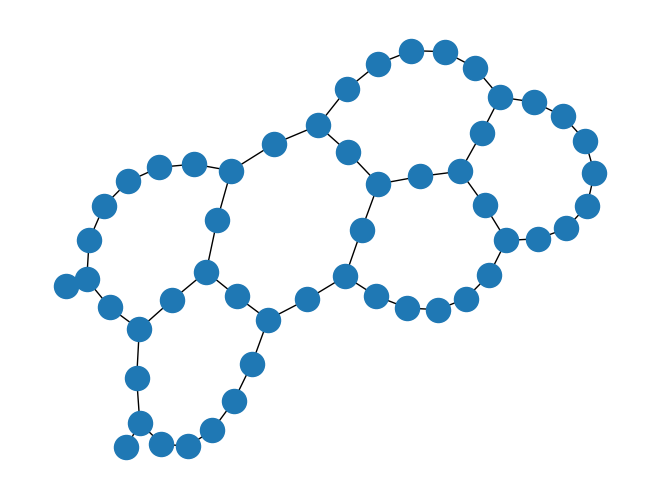

In [8]:
rochester().draw()

### Other available architecture graphs

- IBM Tokyo (20 qubits)
- Google Sycamore (53 qubits)

In [9]:
from architecture import tokyo, sycamore

IBM Tokyo (20 qubits) Quantum Device

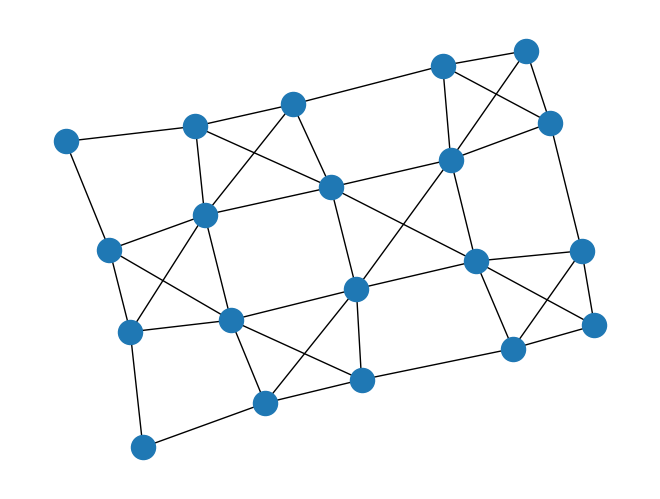

In [10]:
tokyo().draw()

Google Sycamore (53 qubits) Quantum Device

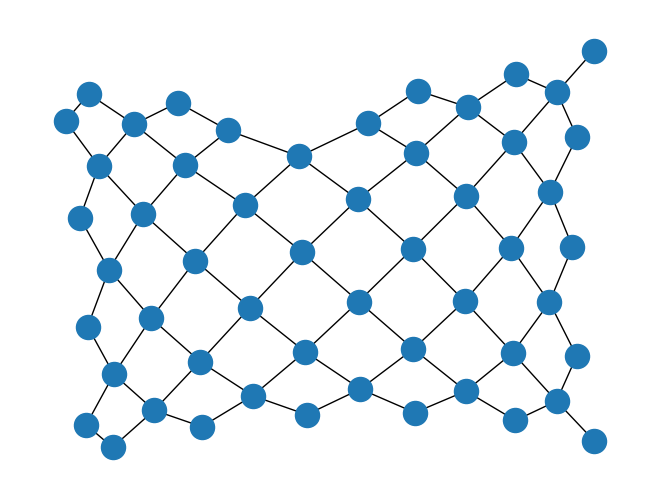

In [11]:
sycamore().draw()

## **S**W**A**P-based **B**idi**RE**ctional heuristic search algorithm (SABRE)

## SABRE mapper

Our SABRE mapper finds a good **initial qubit layout** (logical to physical mapping) by repeatedly simulating circuit execution on the target hardware and inserting SWAPs when needed.

### High level flow

1. **Preprocess the circuit**
   - Keep only 2 qubit gates (SABRE optimises connectivity constraints).
   - Build a `QuantumDAG` from the circuit, and also build a reversed DAG for the backward pass.

2. **Iterative layout search**
   - For each iteration, start from a random initial mapping.
   - Run three passes:
     - **Forward pass** on the original DAG to obtain a final mapping.
     - **Backward pass** on the reversed DAG to refine the mapping.
     - **Forward pass** again to produce the final gate log.
   - Select the iteration with the smallest executed log length (fewest inserted operations).

### Forward pass behaviour

While there are gates remaining in the DAG:

- Collect the **front layer** (gates whose dependencies are satisfied).
- If any front layer 2 qubit gate is executable under the current mapping (adjacent on the architecture graph), execute it and remove it from the DAG.
- Otherwise, generate candidate SWAPs from edges adjacent to the mapped front layer qubits, score each candidate with a heuristic, apply the best SWAP, and continue.

### SWAP scoring heuristic

Each SWAP candidate is scored using:

- **Basic term:** average distance (on the hardware graph) between the mapped qubits of the current front layer gates.
- **Extended term:** average distance for a lookahead window of upcoming gates (extended layer), weighted by `EXTENDED_HEURISTIC_WEIGHT`.
- **Decay factor:** penalises repeatedly using the same physical qubits for SWAPs, controlled by `DECAY_VALUE`.

This encourages SWAP choices that make near-term gates executable while also improving future executability, avoiding local oscillations.

### Outputs

- **Best initial layout:** a `Mapping` from logical qubits to physical qubits.
- Optional **physical execution log**: a sequence of executed 2 qubit gates and inserted `SWAP`s, expressed in physical qubit indices.


### How to use our SABRE mapper

our SABRE expects a Qiskit QuantumCircuit which is decomposed to 1 qubit gates and 2 qubit gates. All 2 qubit gates will be decomposed to only use CX gate. Therefore, we decompose the given circuit as follows:

In [12]:
from decompose import init_circuit
from qiskit import qasm2 # or from qiskit import QuantumCircuit

qc = qasm2.load("data/quekno/20Q_depth_Tokyo/20QBT_depth_Tokyo_large_opt_1_1.5_no.0.qasm")
# old method to load qasm file as Qiskit QuantumCircuit object
# qc = QuantumCircuit.from_qasm_file("data/quekno/20Q_depth_Tokyo/20QBT_depth_Tokyo_large_opt_1_1.5_no.0.qasm")

init_cir = init_circuit(qc, verbose=True)

init_cir.draw(fold=-1)

NO GATES TO DECOMPOSE


┌───┐┌───┐          ┌───┐     ┌───┐                         ┌───┐                              ┌───┐     
 q_0: ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤ X ├┤ H ├──────────┤ X ├─────┤ X ├─────────────────────────┤ X ├──────────────────────────────┤ X ├─────
      ┌───┐┌───┐                                                                      ┌───┐                              └─┬─┘└───┘          └─┬─┘     └─┬─┘                         └─┬─┘                              └─┬─┘     
 q_1: ┤ H ├┤ H ├─────────────────■───────────────────■──────────────■──────────────■──┤ H ├────────────────────────────────┼────■────■─────────┼─────────┼──────────────■──────────────┼─────────────────────────────■────┼───────
      └───┘└───┘                 │            ┌───┐  │  ┌───┐┌───┐  │              │  └───┘     ┌───┐┌───┐┌───┐┌───┐       │    │    │         │         │  ┌───┐┌───┐  │  ┌───┐┌───┐  │  ┌───┐                      │    │       
 q_2: ───────────────────────────┼────────────┤ X ├──┼──┤ H ├┤ H ├──┼──────────────┼────────────┤ X ├┤ H ├┤ H ├┤ H ├───────┼────┼────┼─────────┼─────────┼──┤ X ├┤ H ├──┼──┤ H ├┤ H ├──┼──┤ H ├──────────────────────┼────┼───────
      ┌───┐                      │            └─┬─┘  │  └───┘└───┘  │              │            └─┬─┘└───┘└───┘└───┘       │    │  ┌─┴─┐┌───┐  │         │  └─┬─┘└───┘  │  └───┘└───┘  │  └───┘                    ┌─┴─┐  │       
 q_3: ┤ H ├───────■────■────■────┼─────────■────┼────┼────■─────────┼──────────────┼──────────────┼────────────────────────┼────┼──┤ X ├┤ H ├──┼─────────┼────┼─────────┼────■─────────┼────■───────────────────■──┤ X ├──┼───────
      ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐  │  ┌───┐┌─┴─┐  │    │  ┌─┴─┐┌───┐  │  ┌───┐┌───┐  │              │                        │    │  └───┘└───┘  │  ┌───┐  │    │         │    │         │    │            ┌───┐  │  ├───┤  │       
 q_4: ┤ H ├┤ H ├┤ X ├┤ X ├┤ X ├──┼──┤ H ├┤ X ├──┼────┼──┤ X ├┤ H ├──┼──┤ H ├┤ H ├──┼──────────────┼────────────────────────┼────┼──────────────┼──┤ X ├──┼────┼─────────┼────┼─────────┼────┼────────────┤ X ├──┼──┤ X ├──┼───────
      └───┘└───┘└───┘└───┘├───┤  │  └───┘├───┤  │    │  └───┘├───┤  │  └───┘├───┤  │       ┌───┐  │            ┌───┐┌───┐  │    │  ┌───┐┌───┐  │  └─┬─┘  │    │         │    │  ┌───┐  │    │  ┌───┐┌───┐└─┬─┘  │  └─┬─┘  │  ┌───┐
 q_5: ───────■────────────┤ X ├──┼───────┤ X ├──┼────┼───────┤ X ├──┼───────┤ X ├──┼───────┤ X ├──┼────────────┤ X ├┤ H ├──┼────┼──┤ H ├┤ H ├──┼────┼────┼────┼─────────┼────┼──┤ X ├──┼────┼──┤ X ├┤ H ├──┼────┼────┼────┼──┤ H ├
             │            └─┬─┘  │       └─┬─┘  │    │       └─┬─┘  │       └─┬─┘  │       └─┬─┘  │       ┌───┐└─┬─┘├───┤  │    │  ├───┤└───┘  │    │    │    │         │    │  └─┬─┘  │    │  └─┬─┘└───┘  │    │    │    │  └───┘
 q_6: ──■────┼──────────────┼────┼─────────┼────┼────┼─────────┼────┼─────────┼────┼─────────┼────┼───────┤ X ├──┼──┤ H ├──■────┼──┤ H ├───────■────┼────■────┼─────────┼────┼────┼────■────┼────┼─────────┼────┼────┼────■───────
      ┌─┴─┐  │  ┌───┐┌───┐  │    │  ┌───┐  │    │    │  ┌───┐  │    │  ┌───┐  │    │  ┌───┐  │    │  ┌───┐└─┬─┘  │  └───┘       │  └───┘            │  ┌───┐  │  ┌───┐  │    │    │  ┌───┐  │    │  ┌───┐  │    │    │       ┌───┐
 q_7: ┤ X ├──┼──┤ H ├┤ H ├──┼────┼──┤ H ├──┼────┼────┼──┤ H ├──┼────┼──┤ H ├──┼────┼──┤ H ├──┼────┼──┤ H ├──┼────┼──────────────┼───────────────────┼──┤ X ├──┼──┤ H ├──┼────┼────┼──┤ H ├──┼────┼──┤ X ├──┼────┼────┼───────┤ X ├
      ├───┤  │  └───┘└───┘  │    │  └───┘  │    │    │  └───┘  │    │  └───┘  │    │  └───┘  │    │  └───┘  │    │              │                   │  └─┬─┘  │  └───┘  │    │    │  └───┘  │    │  └─┬─┘  │    │    │       └─┬─┘
 q_8: ┤ H ├──┼──────────────┼────┼─────────┼────┼────┼─────────┼────┼─────────┼────┼─────────┼────┼─────────┼────┼──────────────┼───────────────────■────┼────┼─────────┼────┼────┼─────────┼────┼────┼────■────┼────■─────────┼──
      └───┘  │              │    │ 

with this decomposed circuit, we can find a good initial mapping to place a circuit for a given architecture

In [15]:
from mapper.sabre import sabre_layout

arch = tokyo()
initial_layout = sabre_layout(arch, init_cir, verbose=True, seed=42)

Best Iteration:
#61 total gates
#4 inserted SWAPS

Initial Mapping:
Logical Qubit 0: Physical Qubit 15
Logical Qubit 1: Physical Qubit 4
Logical Qubit 2: Physical Qubit 14
Logical Qubit 3: Physical Qubit 2
Logical Qubit 4: Physical Qubit 6
Logical Qubit 5: Physical Qubit 12
Logical Qubit 6: Physical Qubit 11
Logical Qubit 7: Physical Qubit 5
Logical Qubit 8: Physical Qubit 0
Logical Qubit 9: Physical Qubit 18
Logical Qubit 10: Physical Qubit 8
Logical Qubit 11: Physical Qubit 10
Logical Qubit 12: Physical Qubit 19
Logical Qubit 13: Physical Qubit 3
Logical Qubit 14: Physical Qubit 17
Logical Qubit 15: Physical Qubit 7
Logical Qubit 16: Physical Qubit 9
Logical Qubit 17: Physical Qubit 16
Logical Qubit 18: Physical Qubit 13
Logical Qubit 19: Physical Qubit 1

Physical Gate Log:
CX {} -> 2 6
CX {} -> 11 5
CX {} -> 4 3
CX {} -> 12 17
CX {} -> 13 19
CX {} -> 2 6
CX {} -> 4 3
CX {} -> 18 17
CX {} -> 16 12
CX {} -> 19 14
CX {} -> 13 7
CX {} -> 2 6
CX {} -> 4 3
CX {} -> 18 17
CX {} -> 16 12
C

## SABRE router

The SABRE router takes a **hardware architecture** (`arch`), an input **Qiskit circuit**, and an **initial layout** (logical to physical mapping), then produces a routed circuit by inserting `SWAP`s so every 2 qubit gate becomes executable on the coupling graph.

### Inputs and outputs

- **Inputs**
  - `arch`: coupling graph with `check_gate_executable()` and a shortest path distance matrix.
  - `quantum_circuit`: `QuantumCircuit` to route.
  - `initial_mapping`: initial logical to physical mapping.

- **Outputs**
  - `routed_qc`: a new `QuantumCircuit` on **physical qubits** containing the original gates plus inserted `SWAP`s.
  - `final_mapping`: the ending logical to physical mapping after routing.
  - `log`: a step-by-step record of executed gates and inserted `SWAP`s in physical indices.

### Routing loop

1. Convert the input circuit into a `QuantumDAG` using `from_qiskit(...)`.
2. Repeatedly take the DAG **front layer** (gates whose dependencies are satisfied).
3. Execute all gates that are currently executable:
   - 1 qubit gates always execute immediately.
   - 2 qubit gates execute only if the mapped physical qubits are adjacent in `arch`.
   - Executed gates are emitted into `routed_qc` using `emit_gate_qiskit(...)`, then removed from the DAG.
4. If no front-layer 2 qubit gate is executable, insert a `SWAP`:
   - Generate SWAP candidates from edges adjacent to the mapped front-layer qubits.
   - Score each candidate using a SABRE heuristic based on hardware distances.
   - Apply the best SWAP, update the mapping safely, and append the SWAP to the routed circuit and log.

### SWAP heuristic (lookahead + decay)

Each SWAP candidate is scored by combining:

- **Front-layer cost:** average distance between mapped qubits for current front-layer 2 qubit gates.
- **Extended-layer cost:** average distance for a lookahead window (`EXTENDED_LAYER_SIZE`), weighted by `EXTENDED_HEURISTIC_WEIGHT`.
- **Decay penalty:** discourages repeatedly swapping the same physical qubits, controlled by `DECAY_VALUE` and a short decay timer.

This balances making the next gates executable quickly while also reducing future routing overhead.


### How to use SABRE router

In [16]:
from router.sabre import sabre_swap

routed_circuit, mapping, log = sabre_swap(arch, init_cir, initial_layout)

routed_circuit.draw(fold=-1)

┌───┐                                                  ┌───┐          ┌───┐               
 q_0: ──────────────────────X──┤ X ├──────────────────────────────────────────────────┤ X ├──────────┤ X ├───────────────
                            │  └─┬─┘                                                  └─┬─┘          └─┬─┘               
 q_1: ──────────────────────┼────■─────────────────────────────────────────────────■────■─────────■────■─────────────────
                            │                                               ┌───┐  │  ┌───┐┌───┐  │                      
 q_2: ──■─────────■─────────┼────■─────────■─────────■─────────X─────────■──┤ X ├──┼──┤ X ├┤ X ├──┼──────────────────────
        │  ┌───┐  │  ┌───┐  │    │  ┌───┐  │  ┌───┐  │  ┌───┐  │  ┌───┐  │  └─┬─┘  │  └─┬─┘└─┬─┘  │  ┌───┐               
 q_3: ──┼──┤ X ├──┼──┤ X ├──┼────┼──┤ X ├──┼──┤ X ├──┼──┤ X ├──X──┤ X ├──┼────■────┼────■────■────┼──┤ X ├───────────────
        │  └─┬─┘  │  └─┬─┘  │    │  └─┬─┘  │  └─┬─┘  │  └─┬─┘     └─┬─┘  │         │              │  └─┬─┘               
 q_4: ──┼────■────┼────■────┼────┼────■────┼────■────┼────■─────────■────┼─────────┼─────────■────┼────■─────────────────
        │  ┌───┐  │         │    │         │         │                   │         │         │    │                      
 q_5: ──┼──┤ X ├──┼─────────X────┼─────────┼─────────┼────■────■────■────┼─────────┼─────────┼────┼──────────────────────
      ┌─┴─┐└─┬─┘┌─┴─┐          ┌─┴─┐     ┌─┴─┐     ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐  │         │         │    │                      
 q_6: ┤ X ├──┼──┤ X ├──────────┤ X ├─────┤ X ├─────┤ X ├┤ X ├┤ X ├┤ X ├──┼─────────┼─────────┼────┼──────────────────────
      └───┘  │  └───┘┌───┐     ├───┤     └───┘     └───┘└───┘└───┘└───┘┌─┴─┐     ┌─┴─┐       │  ┌─┴─┐                    
 q_7: ───────┼───────┤ X ├─────┤ X ├──■────■────■──────────────────────┤ X ├─────┤ X ├───────┼──┤ X ├────────────────────
             │       └─┬─┘     └─┬─┘┌─┴─┐┌─┴─┐┌─┴─┐                    └───┘     └───┘     ┌─┴─┐└───┘                    
 q_8: ───────┼─────────┼─────────┼──┤ X ├┤ X ├┤ X ├─────────────────────────────────────X──┤ X ├───────■─────────■────■──
             │         │         │  └───┘└───┘└───┘                                     │  └───┘       │         │  ┌─┴─┐
 q_9: ───────┼─────────┼─────────┼──────────────■───────────────────────────────────────┼──────────────┼─────────┼──┤ X ├
             │         │         │              │                                       │              │         │  └───┘
q_10: ───────┼─────────┼─────────┼─────────X────┼────────────────────────■─────────■────┼────■────■────┼────■────┼───────
             │         │         │  ┌───┐  │    │                        │         │    │    │    │    │    │    │       
q_11: ───────■─────────┼─────────┼──┤ X ├──X────┼────────────────────────┼─────────┼────┼────┼────┼────┼────┼────┼───────
                ┌───┐  │  ┌───┐  │  └─┬─┘┌───┐  │       ┌───┐     ┌───┐  │  ┌───┐  │    │    │    │  ┌─┴─┐  │  ┌─┴─┐     
q_12: ───────■──┤ X ├──┼──┤ X ├──┼────┼──┤ X ├──┼───────┤ X ├─────┤ X ├──┼──┤ X ├──┼────┼────┼────┼──┤ X ├──┼──┤ X ├─────
             │  └─┬─┘  │  └─┬─┘  │    │  └─┬─┘  │       └─┬─┘     └─┬─┘  │  └─┬─┘  │    │    │    │  └───┘  │  └───┘     
q_13: ──■────┼────┼────■────┼────■────┼────┼────┼────■────┼────■────┼────┼────┼────┼────X────┼────┼─────────┼────────────
        │    │    │  ┌───┐  │  ┌───┐  │    │  ┌─┴─┐  │    │    │    │    │    │    │         │    │         │            
q_14: ──┼────┼────┼──┤ X ├──┼──┤ X ├──┼────┼──┤ X ├──┼────┼────┼────┼────┼────┼────┼─────────┼────┼─────────┼────────────
        │    │    │  └─┬─┘  │  └─┬─┘  │    │  └───┘  │    │    │    │  ┌─┴─┐  │  ┌─┴─┐     ┌─┴─┐┌─┴─┐     ┌─┴─┐          
q_15: ──┼────┼────┼────┼────┼────┼────┼────┼─────────┼────┼────┼────┼──┤ X ├──┼──┤ X ├─────┤ X ├┤ X ├─────┤ X ├──────────
        │    │    │    │    │    │    │    │         │    │    │    │  └───┘  │  └───┘     └───┘└───┘     └───┘          
q_16:

## Multi-core processor architecture

`DistributedQubitNetworkGraph` extends `QubitNetworkGraph` to model a **multi core quantum device**. The full graph contains all physical qubits and edges, but the architecture is split into **core subgraphs** (local connectivity) plus **inter core communication edges**.

### Core structure

- `core_node_groups` defines the physical qubits belonging to each core.
- For each core group we extract a local subgraph and union them into `separated_core_graph`.
- The edges are partitioned into:
  - `data_edges`: edges inside `separated_core_graph` (intra core interactions)
  - `comm_edges`: edges in the full graph that are not in `data_edges` (inter core links)
- Communication qubits are identified as nodes incident to `comm_edges` (`comm_qubits`), the rest are `non_comm_qubits`.

### Distance information

- `distance_matrix` is computed on the full graph (including inter core links), and communication edges are assigned a higher weight (default `2`).
- `separated_core_distance_matrix` is computed on `separated_core_graph` (intra core distances only). This is useful when routing should reason about distances without “crossing cores”.

### Gate executability rule

For single core gates, executability is checked against the **intra core graph**:

- 1 qubit gates are always executable.
- 2 qubit gates are executable if the mapped physical qubits are adjacent in `separated_core_graph`.

A special exception exists for distributed execution via telegation:

- If both mapped physical qubits are registered in `active_telegate_nodes`, the gate is treated as executable and the active telegate state is cleared.

### Mapping utilities

`DistributedQubitNetworkGraph` includes helpers for layout and routing decisions:

- ` get_nth_nearest_intracore_free_qubit(...)`: find nearby free qubits within the same core.
- `get_nth_nearest_free_qubit_map(...)`: for each comm qubit, pick the closest free qubit in its core using `separated_core_distance_matrix`.
- `get_full_cores(...)` and `get_core_capacity(...)`: measure available capacity (free physical qubits) per core.
- `draw()` and `draw_mapping(...)`: visualise comm edges separately and overlay the current logical to physical mapping.


### How to construct a multi-core processor architecture

In [19]:
from architecture import DistributedQubitNetworkGraph

def star_line_ring():
    edges_0 = [(0,1), (0,2), (0,3), (0,4), (0,5)]
    edges_1 = [(6,7), (7,8), (8,9), (9,10), (10,11)]
    edges_2 = [(12,13), (13,14), (14,15), (15,16), (16,17), (17,12)]
    edges = edges_0 + edges_1 + edges_2

    comm_edges = [(0,6), (11,12)]
    edges += comm_edges

    core_node_groups = [
        list(range(0, 6)),    # core 0
        list(range(6, 12)),   # core 1
        list(range(12, 18))   # core 2
    ]

    return DistributedQubitNetworkGraph(edges, core_node_groups=core_node_groups, name="Star-Line-Ring (18 Qubits)")


and can be visualised as follows:

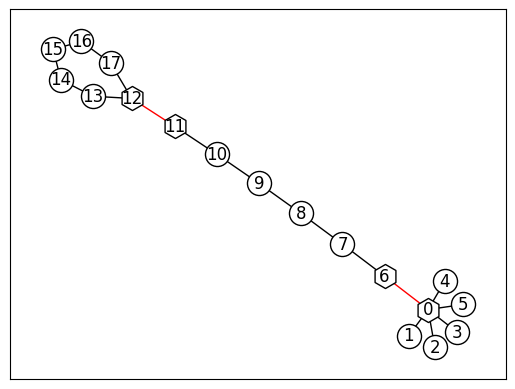

In [20]:
star_line_ring().draw()

### Other available architectures

- Two connected IBM Q Tokyo (40 qubits, 2 cores)
- Four connected IBM Q Tokyo (80 qubits, 4 cores)
- Multi-core Grid(`core_height`, `core_width`, `core_rows`, `core_cols`)

In [21]:
from architecture import two_tokyo, four_tokyo, multi_core_grid

Two connected IBM Q Tokyo (40 qubits, 2 cores)

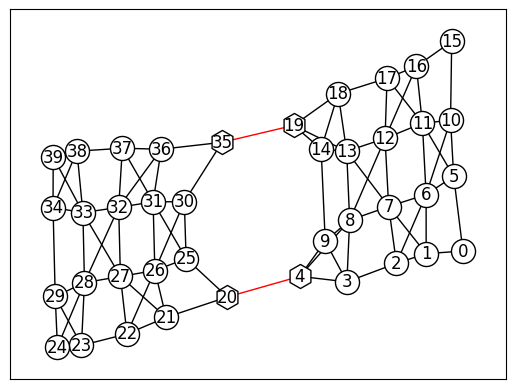

In [22]:
two_tokyo().draw()

Four connected IBM Q Tokyo (80 qubits, 4 cores)

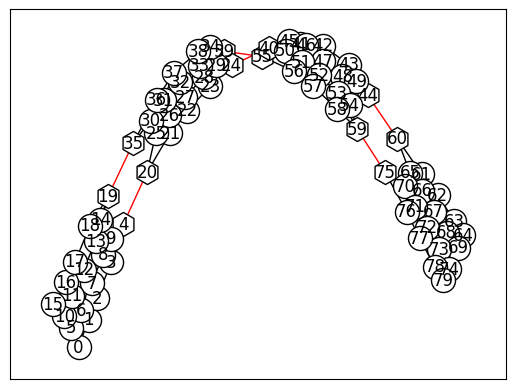

In [23]:
four_tokyo().draw()

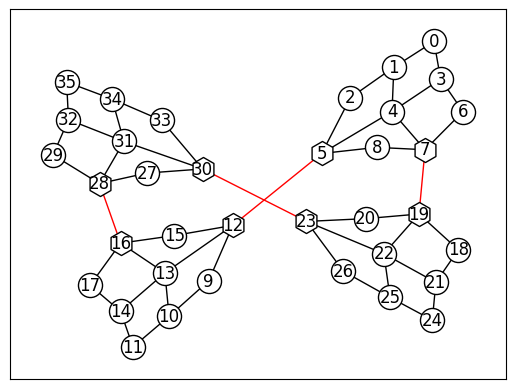

In [24]:
multi_core_grid(3,3,2,2).draw()

## TeleSABRE

TeleSABRE extends SABRE to route and place circuits on a **multi core architecture** (`DistributedQubitNetworkGraph`) where 2 qubit gates are only locally executable inside each core. When a 2 qubit gate spans different cores, TeleSABRE models inter core communication using **teleportation style moves** and uses these moves inside the SABRE search loop.

### Key idea

For each front-layer 2 qubit gate `(q1, q2)`:

- If `q1` and `q2` map to the same core, the gate energy is computed using intra core distance in `separated_core_graph`.
- If they map to different cores, TeleSABRE builds a **contracted communication graph** that includes comm nodes and weighted links, then estimates the cost of routing between the two cores via shortest paths.

This lets TeleSABRE score routing operations that make future inter core gates cheaper.

### Contracted graph model

`DQC_contracted_graph(...)` builds a routing graph that includes:

- all inter core `comm_edges` (weighted by `COMM_EDGE_WEIGHT`)
- the two endpoint physical nodes for the gate
- additional weighted edges inside each core based on `separated_core_distance_matrix`
- penalties and biases:
  - `FULL_CORE_PENALTY` discourages routing through cores with low capacity
  - `CONTRACTED_GRAPH_FREE_NODE_WEIGHT` prefers comm nodes with nearby free qubits
  - optional traffic weights discourage overusing the same comm links

Shortest path length on this contracted graph is treated as the **inter core routing energy**.

### Operation candidates

When no front-layer gate is executable under the current mapping, TeleSABRE chooses one operation from:

- **SWAP** `(p1, p2)` inside a core (from `separated_core_graph`)
- **Teleport** `(p_start, p_comm1, p_comm2)` to move a logical qubit across cores using free comm nodes
- **Telegate** `(p_start, p_comm1, p_comm2, p_target)` which registers a temporary state where an inter core 2 qubit interaction is treated as executable (via `active_telegate_nodes`)

Candidate sets are generated using:
- `get_SWAP_candidates(...)` which focuses on front-layer qubits and free qubits near traversed comm nodes
- `get_teleport_candidates(...)` which proposes valid teleport or telegate patterns based on comm paths and core capacity

### Scoring function

Each candidate operation is scored with `mapping_energy(...)`:

- **Front-layer term:** sum of per gate energies, where inter core gates use contracted graph shortest paths
- **Lookahead term:** same idea applied to the extended layer, weighted by `EXTENDED_HEURISTIC_WEIGHT`
- **Decay:** discourages repeatedly manipulating the same physical endpoints (`DECAY_VALUE`)
- **Teleport bonus:** `TELE_BONUS` encourages selecting teleport/telegate moves when they reduce inter core cost

### Deadlock handling

TeleSABRE tracks progress with timers:

- if the search stalls, `break_deadlock` activates and the scoring focuses on front-layer progress
- if stalling persists and `reset_timer` expires, a `DeadlockError` is raised so the iteration can be discarded

### Layout search (telesabre_layout)

`telesabre_layout(...)` runs multiple randomised iterations:

1. create a random initial mapping that ensures each core has at least one free physical qubit
2. run `sabre_pass` on the forward DAG, then on the reversed DAG, then forward again
3. keep the execution log and choose the best iteration (typically the shortest log)

**Output:** a best initial mapping for distributed execution, optionally with a detailed log.


### How to use TeleSABRE

In [26]:
from mapper.telesabre import telesabre_layout
from decompose import init_circuit
from qiskit import QuantumCircuit

qc = QuantumCircuit.from_qasm_file("./data/telesabre/qasm_25/ae_nativegates_ibm_qiskit_opt3_25.qasm")

init_cir = init_circuit(qc)

arch = two_tokyo()

intial_layout, gate_log = telesabre_layout(arch, init_cir, return_log=True, verbose=True, seed=42, num_iterations=3)


num_free 15 num_cores 2
Architecture configuration is flexible for circuit routing
Iteration 0 ran successfully
Iteration 1 ran successfully
Iteration 2 ran successfully
Best Iteration:
#1597 total gates
#188 inserted SWAPS
#30 inserted teleports
#0 telegates executed

Initial Mapping:
Logical Qubit 0: Physical Qubit 29
Logical Qubit 1: Physical Qubit 38
Logical Qubit 2: Physical Qubit 39
Logical Qubit 3: Physical Qubit 33
Logical Qubit 4: Physical Qubit 37
Logical Qubit 5: Physical Qubit 26
Logical Qubit 6: Physical Qubit 20
Logical Qubit 7: Physical Qubit 22
Logical Qubit 8: Physical Qubit 32
Logical Qubit 9: Physical Qubit 21
Logical Qubit 10: Physical Qubit 27
Logical Qubit 11: Physical Qubit 25
Logical Qubit 12: Physical Qubit 24
Logical Qubit 13: Physical Qubit 34
Logical Qubit 14: Physical Qubit 30
Logical Qubit 15: Physical Qubit 17
Logical Qubit 16: Physical Qubit 14
Logical Qubit 17: Physical Qubit 18
Logical Qubit 18: Physical Qubit 12
Logical Qubit 19: Physical Qubit 8
Logi